This project investigates whether the artists who share festival stages form a network with real, measurable structure, structure strong enough to predict who else an artist is likely to play with, and whether that structure is explained by the music itself or by something else entirely. Festival lineups are expensive, high-stakes decisions: promoters spend months assembling artists to balance genre, audience draw, and cost, largely on the strength of relationships and industry intuition rather than data [1]. A co-performance network, where two artists are linked whenever they share a festival bill, offers a way to test that intuition directly. Built from 2023 lineups at 30 U.S. and international festivals and supplemented with Spotify's track-level audio features, this project asks two questions: does the structure of who-plays-with-whom carry enough signal to predict connections the model hasn't seen, and can that same structure be explained by what the artists actually sound like?

## Building the Network

Nodes in the network are individual artists; an edge connects two artists whenever they performed at the same festival, weighted by how many festivals they shared. Lineups came from official festival posters, most of which exist only as promotional images, so artist names were extracted with Google's Gemini model and manually validated to correct OCR errors and remove hallucinated entries. Artist metadata, danceability, energy, tempo, valence, genre, and popularity, came from a companion Spotify tracks dataset, matched to the network's artist list.

The resulting graph has 3,729 artists and 507,144 edges. It is a single snapshot of the 2023 festival circuit, and it skews heavily toward electronic dance music: EDM festivals account for roughly 37% of the sample, since most large festivals run a dedicated EDM stage or night even when their overall billing is genre-diverse. That skew matters for how the community-detection results below should be read.

## Network Structure: Small-World, Not Random

In [12]:
diameter = nx.diameter(G)
avg_shortest_path_length = nx.average_shortest_path_length(G)
avg_degree = float(np.mean([d for n, d in G.degree()]))
avg_clustering_coeff = nx.average_clustering(G)

metrics = {
        "diameter": diameter,
        "avg_shortest_path": avg_shortest_path_length,
        "avg_degree": avg_degree,
        "avg_clustering_coeff": avg_clustering_coeff
    }

print(metrics)


{'diameter': 4, 'avg_shortest_path': 2.2830746313835304, 'avg_degree': 272.31536604987934, 'avg_clustering_coeff': 0.9236414851854906}


In [13]:
print(f"Density: {nx.density(G)}")

Density: 0.07304596728805776


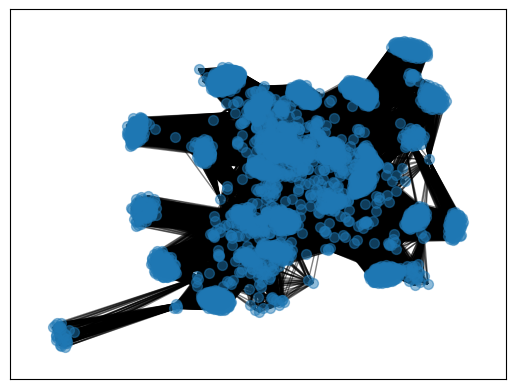

In [14]:
nx.draw_networkx(G, with_labels=False, node_size = 50, alpha=0.5)

A diameter of 4 and an average shortest path of 2.28 mean that almost any two of the network's 3,729 artists are connected through two or three shared festivals, and the clustering coefficient of 0.92 says that artists who share one festival-mate tend to share several more. That combination, short paths and dense local clustering, is the signature of a small-world network.

To check whether that structure was anything more than what density alone would produce, the network was compared against a Watts-Strogatz random-rewiring model matched on node count, edge count, and average degree (Table 1). Even at zero rewiring probability, the Watts-Strogatz model tops out at a clustering coefficient of 0.75, well below the network's observed 0.92, so the real network is meaningfully more clustered than a comparably-sized lattice. Its assortativity coefficient of 0.313 adds another piece to that picture: well-connected artists tend to co-perform with other well-connected artists, a pattern familiar from real-world collaboration networks such as scientific co-authorship.

| Metric | Actual network | Watts-Strogatz |
|---|---|---|
| Nodes | 3,729 | 3,729 |
| Edges | 507,144 | 507,732 |
| Avg. degree | 272.31 | 272.00 |
| Clustering coefficient | 0.923 | 0.745 |
| Density | 0.073 | 0.073 |
| Diameter | 4 | 4 |
| Avg. path length | 2.28 | 2.75 |

## Communities Within the Network

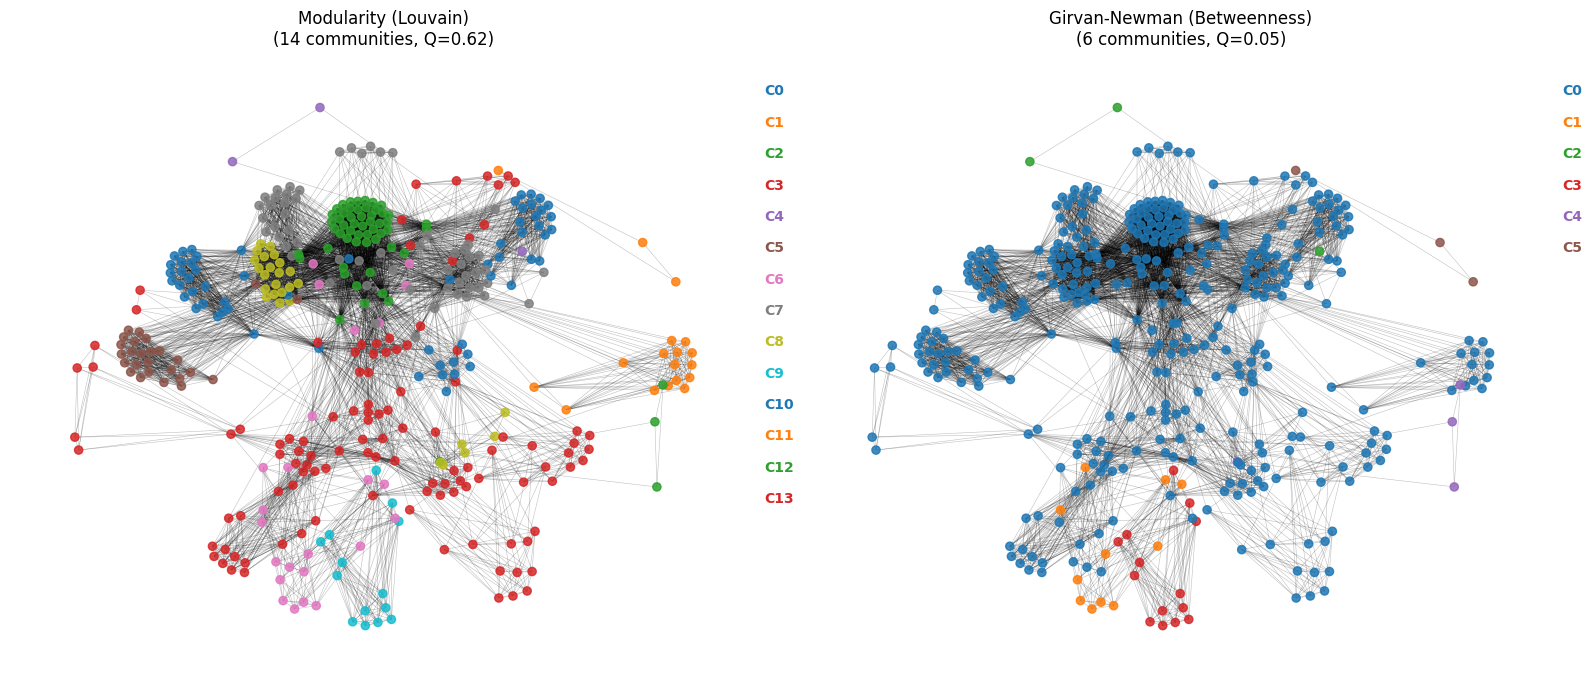

In [22]:
plt.figure(figsize=(16,7))
pos = nx.spring_layout(G_sub, seed=42, k=0.4)
colors = plt.cm.tab10.colors  # up to 10 distinct cluster colors

def draw_network(G_sub, pos, labels, title, mod, colors):
    nx.draw_networkx_nodes(G_sub, pos,
                           node_color=[colors[labels[n] % len(colors)] for n in G_sub],
                           node_size=35, alpha=0.85)
    nx.draw_networkx_edges(G_sub, pos, alpha=0.25, width=0.4)
    plt.title(f"{title}\n({len(set(labels.values()))} communities, Q={mod:.2f})")
    plt.axis("off")

    # vertical cluster labels on the right side
    n_clusters = len(set(labels.values()))
    y_start = 0.95
    y_gap = 0.05
    for i in range(n_clusters):
        plt.text(1.01, y_start - i*y_gap, f"C{i}", color=colors[i % len(colors)],
                 fontsize=10, fontweight='bold', transform=plt.gca().transAxes,
                 verticalalignment='top', horizontalalignment='left')

# Left: Louvain
plt.subplot(1,2,1)
draw_network(G_sub, pos, mod_labels, "Modularity (Louvain)", mod_modularity, colors)

# Right: Girvan-Newman
plt.subplot(1,2,2)
draw_network(G_sub, pos, gn_labels, "Girvan-Newman (Betweenness)", gn_modularity, colors)

plt.tight_layout()
plt.show()

To find substructure inside the larger network, two community-detection algorithms were compared on 10%-node subgraph samples: Louvain modularity optimization and Girvan-Newman edge-betweenness partitioning. Louvain consistently produced tighter, larger communities across every sampled subgraph (modularity Q = 0.66 on one representative sample, versus Q = 0.25 for Girvan-Newman) and was adopted for the full analysis. Girvan-Newman turned out to be a poor fit for this particular network: because the graph is small-world, with an average shortest path of only 2.28, there are many alternate routes between any two artists, so no single edge acts as an obvious bridge for betweenness to detect.

Applying Louvain modularity to the full network, rather than a sample, surfaced 11 distinct communities at a modularity score of 0.60, a strong division for a network this dense. Community sizes range widely, from 948 artists in the largest to 62 in the smallest, which already hints that these clusters are not simply "genre buckets" of equal size.

## The Festivals That Hold It Together

A natural follow-up question: how much of that structure is being driven by a handful of dominant festivals? Modularity clustering was re-run using only the artists who performed at Lollapalooza, Austin City Limits, and Coachella, arguably the three highest-profile U.S. festivals in the dataset.

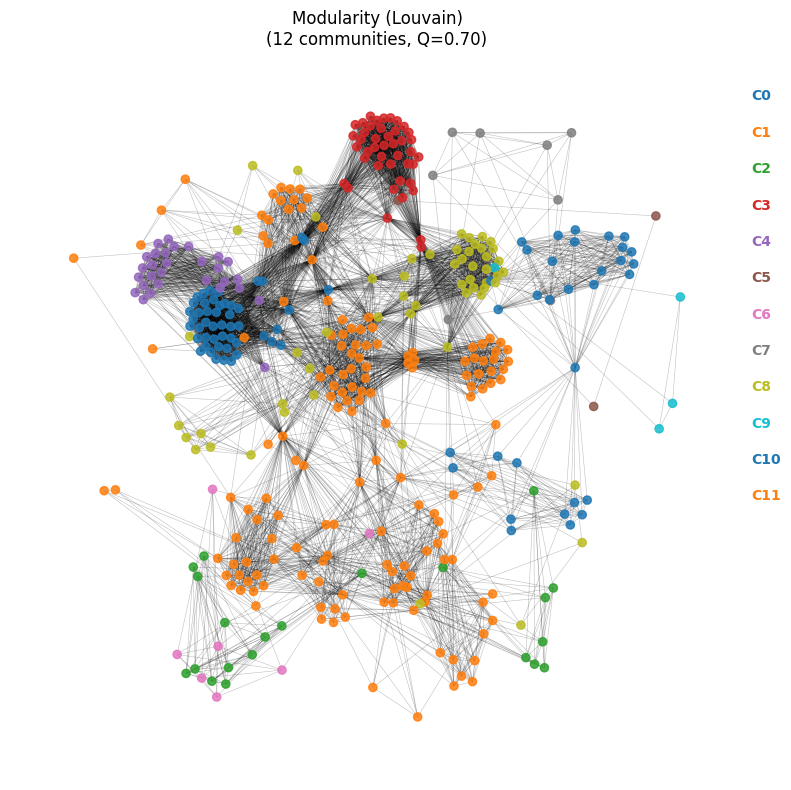

In [26]:
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G_filtered, seed=42, k=0.4)
colors = plt.cm.tab10.colors  # up to 10 distinct cluster colors

def draw_network(G_filtered, pos, labels, title, mod, colors):
    nx.draw_networkx_nodes(G_filtered, pos,
                           node_color=[colors[labels[n] % len(colors)] for n in G_filtered],
                           node_size=35, alpha=0.85)
    nx.draw_networkx_edges(G_filtered, pos, alpha=0.25, width=0.4)
    plt.title(f"{title}\n({len(set(labels.values()))} communities, Q={mod:.2f})")
    plt.axis("off")

    # vertical cluster labels on the right side
    n_clusters = len(set(labels.values()))
    y_start = 0.95
    y_gap = 0.05
    for i in range(n_clusters):
        plt.text(1.01, y_start - i*y_gap, f"C{i}", color=colors[i % len(colors)],
                 fontsize=10, fontweight='bold', transform=plt.gca().transAxes,
                 verticalalignment='top', horizontalalignment='left')

# Louvain
draw_network(G_filtered, pos, mod_labels, "Modularity (Louvain)", mod_modularity, colors)
plt.tight_layout()
plt.show()

### How far does the reach of the big three extend?

Artists who played Lollapalooza, Coachella, or Austin City Limits in 2023 also turned up in roughly 27 of the other 30 festivals in the dataset, domestic and international. No single community from this clustering was confined to just one of the three festivals, so the overlap looks less like three separate artist pools and more like a shared touring circuit that these festivals sit at the center of. A closer read of two of the resulting communities is suggestive without being conclusive: one skewed toward pop headliners, another toward rock and alternative acts, which points to genre as one organizing factor among several, alongside geography and booking relationships.

## Testing the Structure With Link Prediction

Community structure is descriptive; it says the network is organized, not that the organization is useful. To test whether the structure carries real predictive signal, link prediction was framed around one smaller festival, Sunburn, and evaluated under three scenarios designed to avoid the leakage that would come from training and testing on the same festival's edges.

**Case 1** tried to predict links *within* Sunburn's own lineup, using only past co-performance data. **Case 2** predicted links from Sunburn's artists *out* to every other festival's performers, with Sunburn's own edges withheld from training. **Case 3** ran the same out-of-festival prediction, but kept the edges belonging to the three major U.S. festivals (Lollapalooza, Coachella, Austin City Limits) in the training graph.

Predicted probabilities (first 5): [0.04959519 0.05129732 0.12272923 0.04458644 0.06143086]
Predicted labels (first 5): [0 0 0 0 0]

Precision: 0.8154
Recall: 0.1748
F1-score: 0.2879
AUC: 0.7125


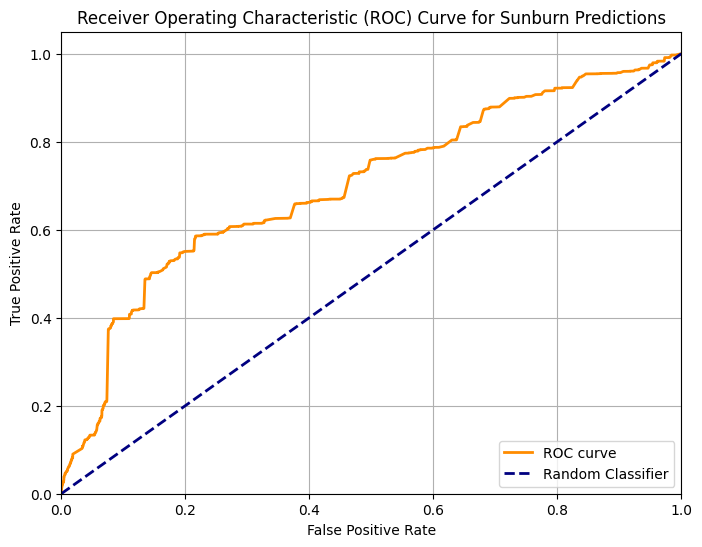

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

y_pred_proba_sunburn = model_sunburn.predict_proba(X_test_sunburn)[:, 1]
y_pred_sunburn = model_sunburn.predict(X_test_sunburn)

print("Predicted probabilities (first 5):", y_pred_proba_sunburn[:5])
print("Predicted labels (first 5):", y_pred_sunburn[:5])

# Calculate classification metrics
precision_sunburn = precision_score(y_test_sunburn, y_pred_sunburn)
recall_sunburn = recall_score(y_test_sunburn, y_pred_sunburn)
f1_sunburn = f1_score(y_test_sunburn, y_pred_sunburn)

print(f"\nPrecision: {precision_sunburn:.4f}")
print(f"Recall: {recall_sunburn:.4f}")
print(f"F1-score: {f1_sunburn:.4f}")

# Calculate Area Under the Receiver Operating Characteristic (ROC) Curve (AUC)
roc_auc_sunburn = roc_auc_score(y_test_sunburn, y_pred_proba_sunburn)
print(f"AUC: {roc_auc_sunburn:.4f}")

# Plot the ROC curve
fpr_sunburn, tpr_sunburn, thresholds_sunburn = roc_curve(y_test_sunburn, y_pred_proba_sunburn)
roc_auc_plot_sunburn = auc(fpr_sunburn, tpr_sunburn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_sunburn, tpr_sunburn, color='darkorange', lw=2, label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Sunburn Predictions')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

<Figure size 800x600 with 0 Axes>

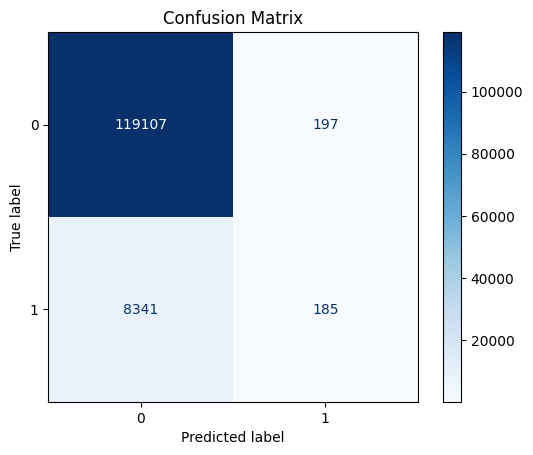

Confusion matrix calculated and displayed.


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_sunburn, y_pred_sunburn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')

plt.show()

print("Confusion matrix calculated and displayed.")

| Scenario | Precision | Recall | F1 | AUC |
|---|---|---|---|---|
| Case 1: within-festival | 0.008 | 0.966 | 0.015 | 0.833 |
| Case 2: cross-festival, majors removed | 0.815 | 0.175 | 0.288 | 0.713 |
| Case 3: cross-festival, majors retained | 0.996 | 0.962 | 0.979 | 0.999 |

The pattern across all three cases points the same direction. Case 1 collapsed on precision (0.008) despite near-perfect recall, because intra-festival connections are so sparse that almost any predicted pair is a false positive. Case 2, shown in the confusion matrix above, was more conservative: moderate precision (0.815) but recall low enough (0.175) that most real Sunburn-to-elsewhere connections went undetected. Case 3 is the standout: with the major festivals' edges left in the training graph, the model predicted Sunburn's external connections almost perfectly (F1 = 0.979, AUC = 0.999). The major festivals are acting as structural anchors, once the model can see how an artist relates to Lollapalooza, Coachella, or Austin City Limits, its connections to the rest of the network become highly predictable. Remove that anchor and prediction degrades sharply. That is strong evidence that a small set of festivals disproportionately shapes the topology of the entire touring circuit.

## Does the Music Explain the Communities?

The second research question flips the first one around: given that Louvain found 11 communities in the network, are those communities separable by what the artists actually sound like, or by genre? If booking patterns tracked musical similarity, community membership should be at least somewhat predictable from Spotify's audio features (danceability, energy, tempo, valence, and similar) and genre metadata.

,count
Community_Label_Mod,
6,948
2,514
10,382
8,374
1,338
5,330
3,244
0,229
7,202



Number of Artists in Community Data: 3729 Artists


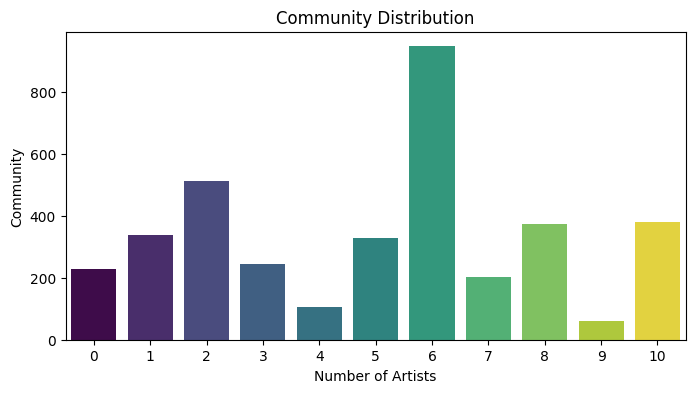

In [ ]:
display(community_data.Community_Label_Mod.value_counts())
print(f'\nNumber of Artists in Community Data: {community_data.Artist.nunique()} Artists')

plt.figure(figsize=(8,4))
sns.countplot(x='Community_Label_Mod',data=community_data, palette='viridis', hue='Community_Label_Mod', legend=False)
plt.title('Community Distribution')
plt.xlabel('Number of Artists')
plt.ylabel('Community')
plt.show()

Four classifiers, logistic regression, a voting ensemble, random forest, and k-nearest neighbors, were trained to predict Louvain community membership from audio and genre features alone.

| Model | Accuracy |
|---|---|
| Logistic Regression | 24.9% |
| Voting Classifier | 19.8% |
| Random Forest | 18.1% |
| KNN | 15.6% |

None of the four came close to reliable classification; logistic regression's 24.9% was the best of a weak field, against a naive baseline of roughly 9% for 11 balanced classes, real but modest signal. The likely explanation is homogeneity rather than randomness: every community, regardless of its position in the network, is dominated by EDM sub-genres and EDM-heavy festivals. Community 1, for instance, is built mostly from artists in minimal techno, hardstyle, drum-and-bass, dub, and house, who mainly performed at EDM-focused festivals like Tomorrowland and EDC, but also turn up at nearly every other festival in the dataset. When every community shares a similar genre mix, genre stops being a useful axis for telling them apart, even though it may still shape the network at a coarser level.

## Conclusion

Structurally, the 2023 festival circuit behaves like a small-world network: short paths, dense local clustering, and a handful of major festivals, Lollapalooza, Austin City Limits, Coachella, acting as hubs that connect otherwise-separate regional and genre-based touring circuits. That structure is not just descriptive; it is predictive, link prediction anchored on those major festivals reconstructed a smaller festival's outside connections with near-perfect accuracy. What the network's structure does not explain is the music itself: the 11 communities Louvain found were not meaningfully separable by audio features or genre, which suggests that co-performance is driven less by how artists sound and more by relationships, geography, and the logistics of who tours where. The circuit runs on connections, and a small number of central festivals hold a disproportionate amount of the network together.

## Limitations

The dataset is a single-year (2023) snapshot, which rules out any analysis of how the network evolves year over year, and it is heavily skewed toward EDM festivals, which likely inflates the apparent lack of musical separability between communities. The network also lacks the business-side metadata, record labels, promoter and agency affiliations, radius clauses limiting how close together an artist can play, that plausibly explain co-performance patterns better than either network topology or musical similarity can. Extending the dataset across multiple years, and incorporating that business context, would be the natural next step for testing whether these findings generalize beyond 2023.

## References

- Hagan, D. (2019). How do the promoters of independent UK music festivals organise and implement events? [University of West London repository](https://repository.uwl.ac.uk/id/eprint/6608/).
- Crossley, N., & Emms, R. (2016). Mapping the Musical Universe: A blockmodel of UK Music Festivals, 2011-13. [Research Explorer, University of Manchester](https://research.manchester.ac.uk/en/publications/mapping-the-musical-universe-a-blockmodel-of-uk-music-festivals-2/).
- Fairy, T. (2025). Data-Driven Talent Booking: Using audience insights to curate a high-demand festival lineup. [Ticket Fairy Promoter Blog](https://www.ticketfairy.com/blog/data-driven-talent-booking-using-audience-insights-to-curate-a-high-demand-festival-lineup).
- Carrier, M. A. (2024). The antitrust case against Live Nation Entertainment. *Harvard Journal of Sports & Entertainment Law*, 15, 2-3.
- Lane, T. (n.d.). Defining unreasonable radius clauses for American music festivals. [Seattle University School of Law Digital Commons](https://digitalcommons.law.seattleu.edu/sulr/vol42/iss3/13/).
- Van Der Hoeven, A., Behr, A., Hamilton, C., Mulder, M., & Rozbicka, P. (2021). 1-2-3-4! Measuring the values of live music: methods, models and motivations. *Arts and the Market*, 11(2), 147-166. [doi:10.1108/aam-09-2020-0041](https://doi.org/10.1108/aam-09-2020-0041).
- Spotify Tracks Dataset. [Hugging Face](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

*Team: Shreya Gupta, Lunden Mandigo, Tyrone Pettygrue, Vaishnavi Venkataraghavan. Course: SI 608, University of Michigan.*